--- TABLA DE DECREMENTOS MÚLTIPLES (Primeros 5 años y Últimos 5 años) ---


,Edad (x),qx_m,qx_w,px_m,px_w,px_tau,tpx_tau
0,30,0.0010,0.150,0.9990,0.850,0.8492,1.0000
1,31,0.0014,0.146,0.9986,0.854,0.8528,0.8492
2,32,0.0018,0.142,0.9982,0.858,0.8565,0.7242
3,33,0.0022,0.138,0.9978,0.862,0.8601,0.6202
4,34,0.0026,0.134,0.9974,0.866,0.8637,0.5334
31,61,0.0134,0.026,0.9866,0.974,0.9609,0.0422
32,62,0.0138,0.022,0.9862,0.978,0.9645,0.0405
33,63,0.0142,0.018,0.9858,0.982,0.9681,0.0391
34,64,0.0146,0.014,0.9854,0.986,0.9716,0.0379
35,65,0.0150,0.010,0.9850,0.990,0.9752,0.0368


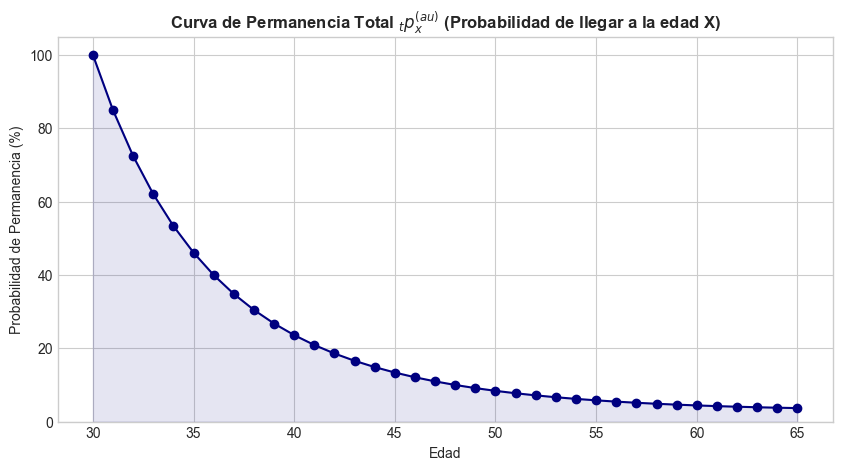

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

# =====================================================================
# MOTOR DE DECREMENTOS MÚLTIPLES (Enfoque Matricial)
# =====================================================================
# 1. Definición del horizonte (Edades de 30 a 65)
edades = np.arange(30, 66)
horizonte = len(edades)

# 2. Generación de tasas absolutas (qx) simuladas
# qx_m: Probabilidad de muerte (Aumenta de 0.1% a 1.5%)
qx_m = np.linspace(0.001, 0.015, horizonte) 
# qx_w: Probabilidad de rotación (Disminuye de 15% a 1% con la antigüedad/edad)
qx_w = np.linspace(0.15, 0.01, horizonte)   

# Construimos el DataFrame del motor actuarial
df_actuarial = pd.DataFrame({'Edad (x)': edades, 'qx_m': qx_m, 'qx_w': qx_w})

# 3. Cálculo de probabilidades aisladas de supervivencia (px = 1 - qx)
df_actuarial['px_m'] = 1 - df_actuarial['qx_m']
df_actuarial['px_w'] = 1 - df_actuarial['qx_w']

# 4. Cálculo de la probabilidad total anual (Independencia de riesgos)
df_actuarial['px_tau'] = df_actuarial['px_m'] * df_actuarial['px_w']

# 5. Cálculo de la cadena de supervivencia (tPx)
# Usamos cumprod() para multiplicar acumulativamente: px_30 * px_31 * px_32...
# Shift(1) y fillna(1.0) aseguran que en el año inicial (edad 30), la supervivencia es 100%
df_actuarial['tpx_tau'] = df_actuarial['px_tau'].cumprod().shift(1).fillna(1.0)

# =====================================================================
# VISUALIZACIÓN DEL MOTOR MATRICIAL
# =====================================================================
print("--- TABLA DE DECREMENTOS MÚLTIPLES (Primeros 5 años y Últimos 5 años) ---")
display(pd.concat([df_actuarial.head(), df_actuarial.tail()]).round(4))

plt.figure(figsize=(10, 5))
plt.plot(df_actuarial['Edad (x)'], df_actuarial['tpx_tau'] * 100, marker='o', color='navy')
plt.title('Curva de Permanencia Total $_tp_x^{(\tau)}$ (Probabilidad de llegar a la edad X)', fontweight='bold')
plt.xlabel('Edad')
plt.ylabel('Probabilidad de Permanencia (%)')
plt.fill_between(df_actuarial['Edad (x)'], df_actuarial['tpx_tau'] * 100, color='navy', alpha=0.1)
plt.ylim(0, 105)
plt.show()

In [2]:
pip install lifelines

  Using cached lifelines-0.30.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached autograd-1.8.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached autograd_gamma-0.5.0-py3-none-any.whl
  Using cached formulaic-1.2.1-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached wrapt-2.2.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (7.4 kB)
Using cached lifelines-0.30.3-py3-none-any.whl (409 kB)
Using cached autograd-1.8.0-py3-none-any.whl (51 kB)
Using cached formulaic-1.2.1-py3-none-any.whl (117 kB)
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
Using cached wrapt-2.2.1-cp312-cp312-macosx_11_0_arm64.whl (81 kB)

[notice] A new release of pip is available: 24.1.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Total de empleados analizados: 2000
Empleados que causaron baja (Evento = 1): 743
Empleados activos / Censurados (Evento = 0): 1257

--- PROBABILIDADES DE RETENCIÓN (Muestra) ---
          Curva de Retención de Talento
timeline                               
0.000000                         1.0000
0.012894                         1.0000
0.018571                         1.0000
0.019809                         1.0000
0.020298                         1.0000
...                                 ...
4.938364                         0.7219
4.938560                         0.7219
4.981669                         0.7206
4.996505                         0.7194
4.997967                         0.7181

[1430 rows x 1 columns]


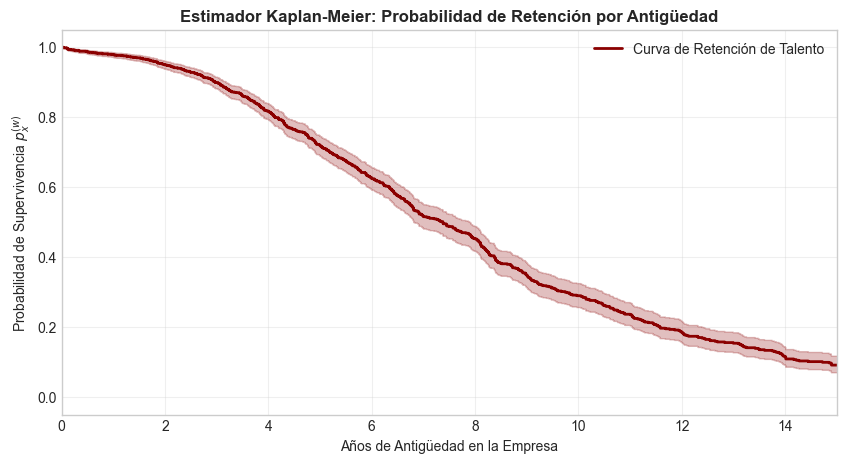

In [3]:
from lifelines import KaplanMeierFitter

# =====================================================================
# SIMULACIÓN DE DATOS DE RECURSOS HUMANOS
# =====================================================================
np.random.seed(42)
n_empleados = 2000

# Simulamos la antigüedad (tenure) usando una distribución exponencial
# Asumimos que la vida media en la empresa es de 4 años
antiguedad_anos = np.random.exponential(scale=4.0, size=n_empleados)

# Simulamos el evento (1 = Renunció/Despedido, 0 = Sigue activo/Censurado)
# Los que tienen menos tiempo tienen más probabilidad de seguir activos
prob_activo = np.clip(1 - (antiguedad_anos / 10), 0.1, 0.9)
evento_baja = np.random.binomial(1, p=(1 - prob_activo))

df_rh = pd.DataFrame({'Antiguedad': antiguedad_anos, 'Baja': evento_baja})

print(f"Total de empleados analizados: {len(df_rh)}")
print(f"Empleados que causaron baja (Evento = 1): {df_rh['Baja'].sum()}")
print(f"Empleados activos / Censurados (Evento = 0): {len(df_rh) - df_rh['Baja'].sum()}\n")

# =====================================================================
# AJUSTE CON KAPLAN-MEIER
# =====================================================================
kmf = KaplanMeierFitter()

# Ajustamos el modelo pasándole la duración y si ocurrió o no el evento
kmf.fit(durations=df_rh['Antiguedad'], event_observed=df_rh['Baja'], label='Curva de Retención de Talento')

# Extraemos las probabilidades de supervivencia exactas para cada año
tabla_supervivencia = kmf.survival_function_

print("--- PROBABILIDADES DE RETENCIÓN (Muestra) ---")
print(tabla_supervivencia.loc[0:5].round(4))

# =====================================================================
# VISUALIZACIÓN KAPLAN-MEIER
# =====================================================================
plt.figure(figsize=(10, 5))
kmf.plot_survival_function(color='darkred', linewidth=2)
plt.title('Estimador Kaplan-Meier: Probabilidad de Retención por Antigüedad', fontweight='bold')
plt.xlabel('Años de Antigüedad en la Empresa')
plt.ylabel('Probabilidad de Supervivencia $p_x^{(w)}$')
plt.grid(True, alpha=0.3)
plt.xlim(0, 15)
plt.show()

--- REPORTE DE VALUACIÓN ACTUARIAL (NIF D-3) ---
Edad actual del empleado:         30 años
Salario Actual:                   $50,000.00
Salario Proyectado (Edad 65):     $233,367.39
Monto del Beneficio Bruto (Pago): $700,102.17
Prob. de llegar a jubilación:     35.00%

➔ RESERVA CONTABLE REQUERIDA HOY: $14,099.01 MXN


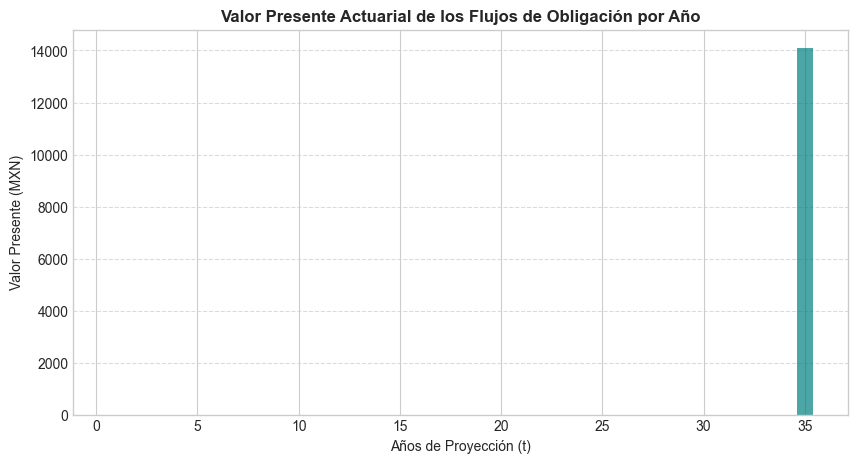

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. PARÁMETROS DEL EMPLEADO Y SUPUESTOS FINANCIEROS
# =====================================================================
edad_actual = 30
edad_jubilacion = 65
horizonte = edad_jubilacion - edad_actual

salario_mensual_actual = 50000  # MXN
meses_de_bono_jubilacion = 3    # El beneficio es de 3 meses de sueldo al jubilarse

tasa_incremento_salarial = 0.045 # 4.5% anual (Inflación + Mérito)
tasa_descuento = 0.085           # 8.5% anual (Curva de Bonos)

# =====================================================================
# 2. VECTORES DE PROYECCIÓN FINANCIERA
# =====================================================================
años_proyeccion = np.arange(1, horizonte + 1)

# A. Proyectamos el salario futuro año con año
salario_proyectado = salario_mensual_actual * (1 + tasa_incremento_salarial)**años_proyeccion

# El beneficio al llegar a la jubilación (año 35) será 3 veces ese último sueldo
beneficio_futuro = np.zeros(horizonte)
beneficio_futuro[-1] = salario_proyectado[-1] * meses_de_bono_jubilacion

# B. Vector de Descuento (Valor Presente)
factor_descuento = 1 / ((1 + tasa_descuento)**años_proyeccion)

# =====================================================================
# 3. RECUPERANDO EL VECTOR ACTUARIAL (Simulado para el ejemplo)
# =====================================================================
# Aquí conectarías la columna 'tpx_tau' que generamos en el motor matricial previo.
# Para hacer este bloque independiente, simularemos la curva de permanencia cayendo al 35%
prob_supervivencia_total = np.linspace(0.95, 0.35, horizonte)

# =====================================================================
# 4. MOTOR DE CÁLCULO DE LA RESERVA (OBLIGACIÓN DBO)
# =====================================================================
# Multiplicamos el Beneficio Esperado * Probabilidad Actuarial * Descuento Financiero
flujo_esperado = beneficio_futuro * prob_supervivencia_total
valor_presente_flujos = flujo_esperado * factor_descuento

# La suma de los valores presentes es el Pasivo Laboral que debe registrarse hoy
pasivo_laboral_total = np.sum(valor_presente_flujos)

# =====================================================================
# 5. SALIDA DE RESULTADOS PARA AUDITORÍA
# =====================================================================
print("--- REPORTE DE VALUACIÓN ACTUARIAL (NIF D-3) ---")
print(f"Edad actual del empleado:         {edad_actual} años")
print(f"Salario Actual:                   ${salario_mensual_actual:,.2f}")
print(f"Salario Proyectado (Edad 65):     ${salario_proyectado[-1]:,.2f}")
print(f"Monto del Beneficio Bruto (Pago): ${beneficio_futuro[-1]:,.2f}")
print(f"Prob. de llegar a jubilación:     {prob_supervivencia_total[-1]*100:.2f}%\n")

print(f"➔ RESERVA CONTABLE REQUERIDA HOY: ${pasivo_laboral_total:,.2f} MXN")

# Gráfico para el Dashboard del cliente
plt.figure(figsize=(10, 5))
plt.bar(años_proyeccion, valor_presente_flujos, color='teal', alpha=0.7)
plt.title('Valor Presente Actuarial de los Flujos de Obligación por Año', fontweight='bold')
plt.xlabel('Años de Proyección (t)')
plt.ylabel('Valor Presente (MXN)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para reportes ejecutivos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_r")

# =====================================================================
# 1. GENERACIÓN DE LA POBLACIÓN LABORAL (EMPRESA SINTÉTICA)
# =====================================================================
np.random.seed(101)
n_empleados = 1000

# Simulamos edades entre 18 y 60 años (distribución realista concentrada en los 35)
edades = np.random.triangular(left=18, mode=35, right=60, size=n_empleados).astype(int)

# Antigüedad lógicamente limitada por la edad (no pueden trabajar antes de los 18)
antiguedad_maxima = edades - 18
antiguedades = np.array([np.random.randint(0, max(1, am)) for am in antiguedad_maxima])

# Salarios mensuales con una distribución log-normal (pocos ganan mucho, muchos ganan el promedio)
salarios_mensuales = np.random.lognormal(mean=9.8, sigma=0.5, size=n_empleados) # Promedio ~22,000 MXN

df_empresa = pd.DataFrame({
    'ID_Empleado': np.arange(1, n_empleados + 1),
    'Edad': edades,
    'Antigüedad': antiguedades,
    'Salario_Mensual': salarios_mensuales
})

# =====================================================================
# 2. SUPUESTOS ACTUARIALES CONTRACTUALES Y MACROECONÓMICOS
# =====================================================================
EDAD_JUBILACION = 65
TASA_DESCUENTO = 0.0875          # 8.75% Tasa de rendimiento de bonos corporativos/gubernamentales
TASA_INCREMENTO_SALARIAL = 0.045 # 4.50% Proyección de inflación + mérito salarial

# =====================================================================
# 3. MOTOR VECTORIZADO DE VALUACIÓN (NIF D-3 / IAS 19)
# =====================================================================
def calcular_pasivo_corporativo(df, tasa_desc, tasa_sal):
    df_calc = df.copy()
    
    # Años faltantes para el evento de jubilación
    df_calc['Años_Faltantes'] = EDAD_JUBILACION - df_calc['Edad']
    
    # Proyección del Salario al momento del retiro
    df_calc['Salario_Proyectado'] = df_calc['Salario_Mensual'] * (1 + tasa_sal)**df_calc['Años_Faltantes']
    
    # Plan de beneficio: 3 meses de sueldo final como prima de antigüedad/jubilación
    df_calc['Beneficio_Futuro'] = df_calc['Salario_Proyectado'] * 3
    
    # Supuesto actuarial de permanencia (Decrementos combinados: rotación + mortalidad)
    # Entre más años le falten al empleado, menor es su probabilidad de quedarse hasta el final
    df_calc['Prob_Permanencia_Acumulada'] = 0.95 ** df_calc['Años_Faltantes']
    
    # Descuento Financiero (Valor Presente)
    df_calc['Factor_Descuento'] = 1 / ((1 + tasa_desc)**df_calc['Años_Faltantes'])
    
    # Obligación por Beneficios Definidos (DBO) Individual
    df_calc['DBO'] = df_calc['Beneficio_Futuro'] * df_calc['Prob_Permanencia_Acumulada'] * df_calc['Factor_Descuento']
    
    return df_calc

# Ejecución del motor base
df_valuado = calcular_pasivo_corporativo(df_empresa, TASA_DESCUENTO, TASA_INCREMENTO_SALARIAL)

             DICTAMEN DE VALUACIÓN ACTUARIAL - RESUMEN          
Número de Empleados Valuados:        1,000
Edad Promedio de la Población:       37.1 años
Antigüedad Promedio en la Empresa:   9.2 años
Nómina Anual Corriente (Bruta):      $248,105,285.14 MXN
----------------------------------------------------------------
OBLIGACIÓN POR BENEFICIOS DEFINIDOS (DBO): $6,681,826.55 MXN
Pasivo como % de la Nómina Anual:    2.69%

--- DISTRIBUCIÓN DEL PASIVO POR GRUPOS DE EDAD ---


,Grupo_Edad,Num_Empleados,DBO_Total,%_Del_Pasivo_Total
0,<25,91,"$124,096.20",1.86%
1,25-35,371,"$1,098,574.69",16.44%
2,35-45,352,"$2,290,841.56",34.28%
3,45-55,172,"$2,756,925.41",41.26%
4,55+,14,"$411,388.68",6.16%


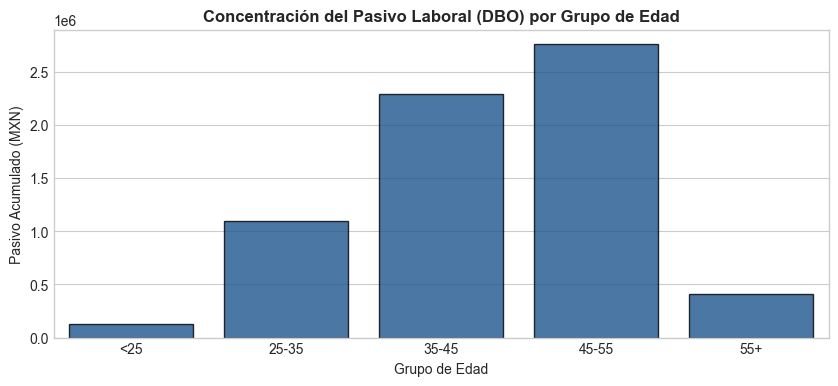

In [2]:
# =====================================================================
# 4. AGREGACIÓN DE DATOS PARA PRESENTACIÓN INSTITUCIONAL
# =====================================================================
dbo_total = df_valuado['DBO'].sum()
salario_anual_total = (df_valuado['Salario_Mensual'] * 12).sum()
edad_promedio = df_valuado['Edad'].mean()
antiguedad_promedio = df_valuado['Antigüedad'].mean()

print("================================================================")
print("             DICTAMEN DE VALUACIÓN ACTUARIAL - RESUMEN          ")
print("================================================================")
print(f"Número de Empleados Valuados:        {n_empleados:,}")
print(f"Edad Promedio de la Población:       {edad_promedio:.1f} años")
print(f"Antigüedad Promedio en la Empresa:   {antiguedad_promedio:.1f} años")
print(f"Nómina Anual Corriente (Bruta):      ${salario_anual_total:,.2f} MXN")
print("----------------------------------------------------------------")
print(f"OBLIGACIÓN POR BENEFICIOS DEFINIDOS (DBO): ${dbo_total:,.2f} MXN")
print(f"Pasivo como % de la Nómina Anual:    {(dbo_total / salario_anual_total)*100:.2f}%")
print("================================================================")

# =====================================================================
# 5. ANÁLISIS DE CONCENTRACIÓN POR GRUPOS DE EDAD
# =====================================================================
# Los clientes corporativos necesitan ver dónde se concentra el riesgo de fondeo
df_valuado['Grupo_Edad'] = pd.cut(df_valuado['Edad'], bins=[0, 25, 35, 45, 55, 65], 
                                  labels=['<25', '25-35', '35-45', '45-55', '55+'])

reporte_grupos = df_valuado.groupby('Grupo_Edad', observed=False).agg(
    Num_Empleados=('ID_Empleado', 'count'),
    DBO_Total=('DBO', 'sum')
).reset_index()

reporte_grupos['%_Del_Pasivo_Total'] = (reporte_grupos['DBO_Total'] / dbo_total) * 100

print("\n--- DISTRIBUCIÓN DEL PASIVO POR GRUPOS DE EDAD ---")
display(reporte_grupos.style.format({
    'Num_Empleados': '{:,}',
    'DBO_Total': '${:,.2f}',
    '%_Del_Pasivo_Total': '{:.2f}%'
}))

# Gráfico de distribución para el reporte técnico del cliente
plt.figure(figsize=(10, 4))
sns.barplot(x='Grupo_Edad', y='DBO_Total', data=reporte_grupos, edgecolor='black', alpha=0.8)
plt.title('Concentración del Pasivo Laboral (DBO) por Grupo de Edad', fontweight='bold', fontsize=12)
plt.xlabel('Grupo de Edad')
plt.ylabel('Pasivo Acumulado (MXN)')
plt.show()

In [3]:
# =====================================================================
# 6. ANÁLISIS DE SENSIBILIDAD (ESTRÉS DE TASAS DE INTERÉS)
# =====================================================================
# Escenario de Alza de Tasas (+1.00%) -> El pasivo debe disminuir
df_tasas_altas = calcular_pasivo_corporativo(df_empresa, TASA_DESCUENTO + 0.01, TASA_INCREMENTO_SALARIAL)
dbo_tasas_altas = df_tasas_altas['DBO'].sum()

# Escenario de Baja de Tasas (-1.00%) -> El pasivo debe aumentar
df_tasas_bajas = calcular_pasivo_corporativo(df_empresa, TASA_DESCUENTO - 0.01, TASA_INCREMENTO_SALARIAL)
dbo_tasas_bajas = df_tasas_bajas['DBO'].sum()

# Estructuración de la tabla de sensibilidad requerida por auditores externos
tabla_sensibilidad = pd.DataFrame({
    'Escenario': ['Tasa de Descuento Mínima (7.75%)', 'Escenario Base (8.75%)', 'Tasa de Descuento Máxima (9.75%)'],
    'DBO Total (MXN)': [dbo_tasas_bajas, dbo_total, dbo_tasas_altas],
    'Impacto Absoluto (MXN)': [dbo_tasas_bajas - dbo_total, 0.0, dbo_tasas_altas - dbo_total],
    'Impacto Porcentual': [((dbo_tasas_bajas / dbo_total) - 1) * 100, 0.0, ((dbo_tasas_altas / dbo_total) - 1) * 100]
})

print("\n================================================================")
print("     NOTA REVELATORIA: ANÁLISIS DE SENSIBILIDAD DE LA DBO      ")
print("================================================================")
display(tabla_sensibilidad.style.format({
    'DBO Total (MXN)': '${:,.2f}',
    'Impacto Absoluto (MXN)': '${:+,.2f}',
    'Impacto Porcentual': '{:+.2f}%'
}))


     NOTA REVELATORIA: ANÁLISIS DE SENSIBILIDAD DE LA DBO      


,Escenario,DBO Total (MXN),Impacto Absoluto (MXN),Impacto Porcentual
0,Tasa de Descuento Mínima (7.75%),"$8,142,721.67","$+1,460,895.12",+21.86%
1,Escenario Base (8.75%),"$6,681,826.55",$+0.00,+0.00%
2,Tasa de Descuento Máxima (9.75%),"$5,525,023.57","$-1,156,802.98",-17.31%


Ejecutando motor de valuación para 10,000 escenarios...
✅ Valuación estocástica finalizada.

     REPORTE DE RIESGO ACTUARIAL EXTREMO (STOCHASTIC ALM)       
Obligación Promedio Esperada:      $6,902,707.69 MXN
Actuarial VaR (95% Confianza):     $9,779,696.94 MXN
Actuarial VaR (99% Confianza):     $11,596,543.32 MXN
----------------------------------------------------------------
Capital de Respaldo Requerido:     $4,693,835.63 MXN


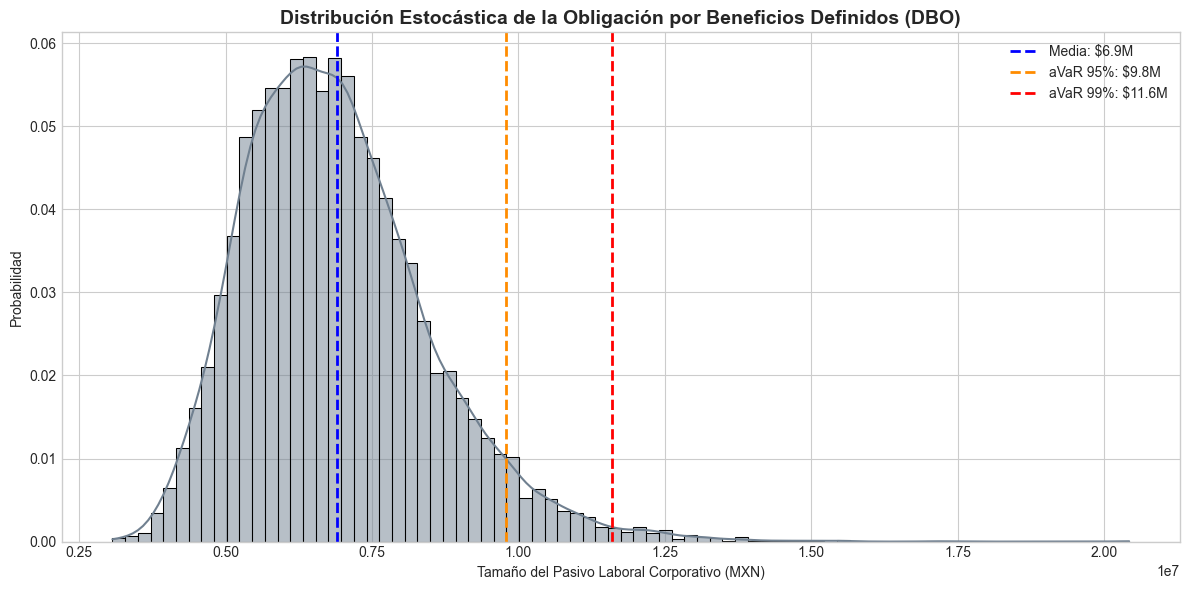

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# =====================================================================
# 1. PARÁMETROS MACROECONÓMICOS ESTOCÁSTICOS
# =====================================================================
simulaciones = 10000

# Medias históricas (Los escenarios base del cliente)
mu_r = 0.0875  # Tasa de descuento promedio
mu_i = 0.0450  # Incremento salarial promedio

# Volatilidades (Desviación estándar histórica de las tasas)
sigma_r = 0.0150 # 150 puntos base de volatilidad en la curva
sigma_i = 0.0100 # 100 puntos base de volatilidad en la inflación/sueldos

# Correlación entre tasas de interés e inflación salarial
# Suele ser positiva: inflación alta -> tasas altas
rho = 0.65 

# =====================================================================
# 2. SIMULACIÓN CORRELACIONADA (DESCOMPOSICIÓN DE CHOLESKY)
# =====================================================================
np.random.seed(42)
# Generamos variables normales independientes
X1 = np.random.standard_normal(simulaciones)
X2 = np.random.standard_normal(simulaciones)

# Aplicamos Cholesky
Z_r = X1
Z_i = rho * X1 + np.sqrt(1 - rho**2) * X2

# Tasas finales simuladas
tasas_descuento_sim = mu_r + sigma_r * Z_r
tasas_salariales_sim = mu_i + sigma_i * Z_i

# Limitamos para evitar tasas económicamente ilógicas (menores a 0%)
tasas_descuento_sim = np.clip(tasas_descuento_sim, 0.01, 0.20)
tasas_salariales_sim = np.clip(tasas_salariales_sim, 0.01, 0.15)

# =====================================================================
# 3. MOTOR VECTORIZADO (10,000 Valuaciones Corporativas)
# =====================================================================
# Pre-calculamos los años faltantes para optimizar
años_faltantes = (65 - df_empresa['Edad']).values
salarios_actuales = df_empresa['Salario_Mensual'].values
prob_permanencia = 0.95 ** años_faltantes

# Arreglo para guardar el Pasivo Total (DBO) de cada escenario
dbo_escenarios = np.zeros(simulaciones)

print(f"Ejecutando motor de valuación para {simulaciones:,} escenarios...")

# Iteramos sobre los escenarios macroeconómicos
for s in range(simulaciones):
    # Proyectamos salarios y descontamos usando las tasas del escenario 's'
    r_s = tasas_descuento_sim[s]
    i_s = tasas_salariales_sim[s]
    
    salario_proyectado = salarios_actuales * (1 + i_s)**años_faltantes
    beneficio_futuro = salario_proyectado * 3
    factor_descuento = 1 / ((1 + r_s)**años_faltantes)
    
    # Calculamos el DBO individual y sumamos para obtener el DBO corporativo del escenario
    dbo_individual = beneficio_futuro * prob_permanencia * factor_descuento
    dbo_escenarios[s] = np.sum(dbo_individual)

print("✅ Valuación estocástica finalizada.\n")

# =====================================================================
# 4. ANÁLISIS DE RIESGO: ACTUARIAL VALUE AT RISK (aVaR)
# =====================================================================
# El escenario base (promedio determinista)
dbo_promedio = np.mean(dbo_escenarios)

# aVaR al 95% y 99% de confianza (Percentiles de la cola derecha, porque aquí el riesgo es que el pasivo sea MAYOR)
avar_95 = np.percentile(dbo_escenarios, 95)
avar_99 = np.percentile(dbo_escenarios, 99)

print("================================================================")
print("     REPORTE DE RIESGO ACTUARIAL EXTREMO (STOCHASTIC ALM)       ")
print("================================================================")
print(f"Obligación Promedio Esperada:      ${dbo_promedio:,.2f} MXN")
print(f"Actuarial VaR (95% Confianza):     ${avar_95:,.2f} MXN")
print(f"Actuarial VaR (99% Confianza):     ${avar_99:,.2f} MXN")
print("----------------------------------------------------------------")
print(f"Capital de Respaldo Requerido:     ${(avar_99 - dbo_promedio):,.2f} MXN")
print("================================================================")

# =====================================================================
# 5. VISUALIZACIÓN DEL aVaR
# =====================================================================
plt.figure(figsize=(12, 6))
sns.histplot(dbo_escenarios, bins=80, kde=True, color='slategray', stat='probability')

# Líneas de Riesgo
plt.axvline(dbo_promedio, color='blue', linestyle='--', linewidth=2, label=f'Media: ${dbo_promedio/1e6:.1f}M')
plt.axvline(avar_95, color='darkorange', linestyle='--', linewidth=2, label=f'aVaR 95%: ${avar_95/1e6:.1f}M')
plt.axvline(avar_99, color='red', linestyle='--', linewidth=2, label=f'aVaR 99%: ${avar_99/1e6:.1f}M')

plt.title('Distribución Estocástica de la Obligación por Beneficios Definidos (DBO)', fontweight='bold', fontsize=14)
plt.xlabel('Tamaño del Pasivo Laboral Corporativo (MXN)')
plt.ylabel('Probabilidad')
plt.legend()
plt.tight_layout()
plt.show()

--- MÉTRICAS DE RIESGO ESTRUCTURAL (PASIVOS) ---
Valor Presente de Obligaciones (VPO): $311.98 M
Duración de Macaulay (D_Mac):         11.63 años
Duración Modificada (D_Mod):          10.69 % por cada 1% de tasa
Convexidad (C):                       162.39
------------------------------------------------
Escenario: Choque de Tasas de +200 bps (+2.0%)
Caída estimada por Duración:          -21.39%
Efecto amortiguador de Convexidad:    +3.25%
Impacto Neto en el VPO:               -18.14%
Nuevo VPO Estimado:                   $255.38 M


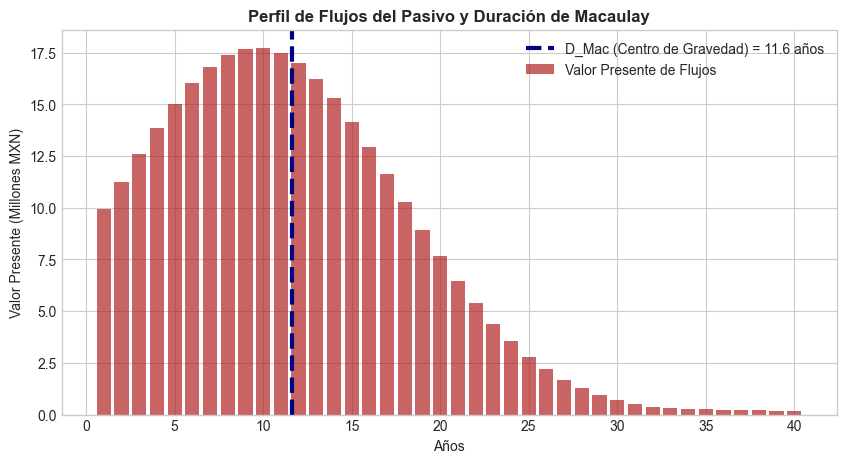

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. SIMULACIÓN DE FLUJOS DEL PASIVO LABORAL
# =====================================================================
# Simulamos los flujos de efectivo proyectados (pagos de jubilación) 
# de la empresa para los próximos 40 años (en millones de pesos).
# (Suelen tener forma de campana: pocos pagos hoy, muchos cuando el grueso
# de la población llega a los 65 años, y luego baja por mortalidad).

horizonte = np.arange(1, 41)
flujos_esperados = norm.pdf(horizonte, loc=15, scale=8) * 1000 
flujos_esperados = np.maximum(flujos_esperados, 5) # Piso mínimo de pagos

tasa_descuento = 0.0875 # 8.75%

# =====================================================================
# 2. CÁLCULO DE DURACIÓN Y CONVEXIDAD
# =====================================================================
# A. Valor Presente de cada flujo
factor_descuento = 1 / ((1 + tasa_descuento)**horizonte)
pv_flujos = flujos_esperados * factor_descuento
vpo_total = np.sum(pv_flujos)

# B. Duración de Macaulay
pesos = pv_flujos / vpo_total
d_mac = np.sum(horizonte * pesos)

# C. Duración Modificada
d_mod = d_mac / (1 + tasa_descuento)

# D. Convexidad
convexidad = np.sum((horizonte * (horizonte + 1) * flujos_esperados) / ((1 + tasa_descuento)**(horizonte + 2)))
convexidad_final = convexidad / vpo_total

# =====================================================================
# 3. IMPACTO FINANCIERO (APROXIMACIÓN DE TAYLOR)
# =====================================================================
# Si el Banco de México sube la tasa violentamente en 200 puntos base (2.0%)
choque_tasa = 0.0200 

# Cambio en precio usando solo Duración (Línea recta)
cambio_duracion = -d_mod * choque_tasa

# Mejora usando Convexidad (Curva real)
cambio_convexidad = 0.5 * convexidad_final * (choque_tasa**2)

cambio_total_estimado = cambio_duracion + cambio_convexidad
nuevo_vpo_estimado = vpo_total * (1 + cambio_total_estimado)

# =====================================================================
# 4. REPORTE AL COMITÉ DE RIESGOS (ALCO)
# =====================================================================
print("--- MÉTRICAS DE RIESGO ESTRUCTURAL (PASIVOS) ---")
print(f"Valor Presente de Obligaciones (VPO): ${vpo_total:,.2f} M")
print(f"Duración de Macaulay (D_Mac):         {d_mac:.2f} años")
print(f"Duración Modificada (D_Mod):          {d_mod:.2f} % por cada 1% de tasa")
print(f"Convexidad (C):                       {convexidad_final:.2f}")
print("------------------------------------------------")
print(f"Escenario: Choque de Tasas de +200 bps (+2.0%)")
print(f"Caída estimada por Duración:          {cambio_duracion*100:.2f}%")
print(f"Efecto amortiguador de Convexidad:    +{cambio_convexidad*100:.2f}%")
print(f"Impacto Neto en el VPO:               {cambio_total_estimado*100:.2f}%")
print(f"Nuevo VPO Estimado:                   ${nuevo_vpo_estimado:,.2f} M")

# Gráfico de flujos para visualizar el "Centro de Gravedad"
plt.figure(figsize=(10, 5))
plt.bar(horizonte, pv_flujos, color='firebrick', alpha=0.7, label='Valor Presente de Flujos')
plt.axvline(d_mac, color='navy', linestyle='--', linewidth=3, label=f'D_Mac (Centro de Gravedad) = {d_mac:.1f} años')
plt.title('Perfil de Flujos del Pasivo y Duración de Macaulay', fontweight='bold')
plt.xlabel('Años')
plt.ylabel('Valor Presente (Millones MXN)')
plt.legend()
plt.show()

--- OBJETIVO DE INMUNIZACIÓN (PASIVO) ---
Valor a cubrir:   $1,250.50 M
Duración Target:  9.50 años

--- INSTRUMENTOS DISPONIBLES ---
Mbono 10Y -> Precio: 91.78 | Duración: 7.07 años
Mbono 30Y -> Precio: 97.36 | Duración: 11.06 años

--- ESTRATEGIA DE PORTAFOLIO ALM (HEDGE) ---
Peso Mbono 10Y: 39.06% -> Invertir: $488.45 M (5,321,943 títulos)
Peso Mbono 30Y: 60.94% -> Invertir: $762.05 M (7,826,952 títulos)

✅ Duración del Portafolio Sintético: 9.50 años (Match perfecto)


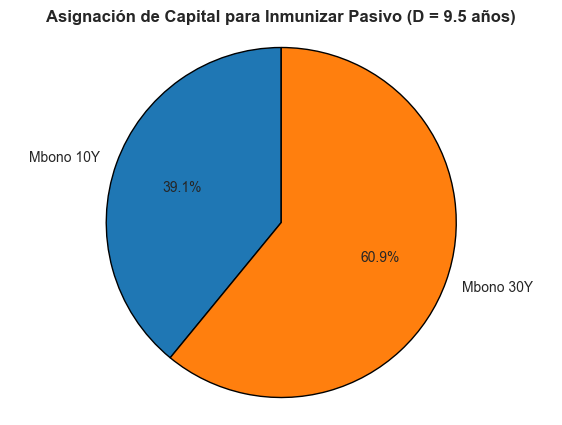

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. RECUPERANDO LOS DATOS DEL PASIVO 
# =====================================================================
vpo_pasivo = 1250.50  # Millones de MXN
d_mac_pasivo = 9.5    # Años (¡Ajustado para que el hedge sea posible!)
tasa_mercado = 0.0875 # 8.75%

print("--- OBJETIVO DE INMUNIZACIÓN (PASIVO) ---")
print(f"Valor a cubrir:   ${vpo_pasivo:,.2f} M")
print(f"Duración Target:  {d_mac_pasivo:.2f} años\n")

# =====================================================================
# 2. LOS INSTRUMENTOS DEL MERCADO (MBONOS)
# =====================================================================
# Mbono a 10 años (Tasa cupón del 7.50% anual, pagos semestrales)
plazo_1 = 10
cupon_1 = 0.075 / 2
flujos_1 = np.full(plazo_1 * 2, cupon_1 * 100)
flujos_1[-1] += 100 # Devolución del principal
periodos_1 = np.arange(1, plazo_1 * 2 + 1) / 2
pv_flujos_1 = flujos_1 / ((1 + tasa_mercado/2)**(periodos_1 * 2))
precio_1 = np.sum(pv_flujos_1)
d_mac_1 = np.sum(periodos_1 * (pv_flujos_1 / precio_1))

# Mbono a 30 años (Tasa cupón del 8.50% anual, pagos semestrales)
plazo_2 = 30
cupon_2 = 0.085 / 2
flujos_2 = np.full(plazo_2 * 2, cupon_2 * 100)
flujos_2[-1] += 100
periodos_2 = np.arange(1, plazo_2 * 2 + 1) / 2
pv_flujos_2 = flujos_2 / ((1 + tasa_mercado/2)**(periodos_2 * 2))
precio_2 = np.sum(pv_flujos_2)
d_mac_2 = np.sum(periodos_2 * (pv_flujos_2 / precio_2))

print("--- INSTRUMENTOS DISPONIBLES ---")
print(f"Mbono 10Y -> Precio: {precio_1:.2f} | Duración: {d_mac_1:.2f} años")
print(f"Mbono 30Y -> Precio: {precio_2:.2f} | Duración: {d_mac_2:.2f} años\n")

# =====================================================================
# 3. EL MOTOR DE OPTIMIZACIÓN ALGEBRAICA
# =====================================================================
# Aplicamos la fórmula de pesos para empatar la duración
w_1 = (d_mac_2 - d_mac_pasivo) / (d_mac_2 - d_mac_1)
w_2 = 1 - w_1

# Dinero a invertir en cada bono (En millones de MXN)
inversion_bono_1 = w_1 * vpo_pasivo
inversion_bono_2 = w_2 * vpo_pasivo

# Cantidad de títulos a comprar (Asumiendo valor nominal de $100)
titulos_1 = (inversion_bono_1 * 1_000_000) / precio_1
titulos_2 = (inversion_bono_2 * 1_000_000) / precio_2

print("--- ESTRATEGIA DE PORTAFOLIO ALM (HEDGE) ---")
print(f"Peso Mbono 10Y: {w_1*100:.2f}% -> Invertir: ${inversion_bono_1:,.2f} M ({titulos_1:,.0f} títulos)")
print(f"Peso Mbono 30Y: {w_2*100:.2f}% -> Invertir: ${inversion_bono_2:,.2f} M ({titulos_2:,.0f} títulos)")

# Comprobación de seguridad matemática
duracion_portafolio = (w_1 * d_mac_1) + (w_2 * d_mac_2)
print(f"\n✅ Duración del Portafolio Sintético: {duracion_portafolio:.2f} años (Match perfecto)")

# =====================================================================
# 4. VISUALIZACIÓN DE LA COBERTURA
# =====================================================================
labels = ['Mbono 10Y', 'Mbono 30Y']
sizes = [inversion_bono_1, inversion_bono_2]
colors = ['#1f77b4', '#ff7f0e']

plt.figure(figsize=(7, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title(f'Asignación de Capital para Inmunizar Pasivo (D = {d_mac_pasivo:.1f} años)', fontweight='bold')
plt.axis('equal') 
plt.show()